In [ ]:
#Import Libraries
import numpy as np                    #numerical operations
import pandas as pd                   #dataset handling
import matplotlib.pyplot as plt       #data visualization
import seaborn as sns                 #data visualization

from sklearn.model_selection import train_test_split                                    #splits dataset into training/testing
from sklearn.preprocessing import LabelEncoder                                          #converts text into numbers                                         #
from sklearn.ensemble import RandomForestClassifier                                     #ML algorithm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report     #evaluate model performance

In [ ]:
df=pd.read_csv('/content/loan_approval_dataset.csv')      #Load Dataset
df                                                        #Display Dataset

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [ ]:
df.info()           #Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [ ]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
df.isnull().sum() #equal to df.isna().sum()     Check Missing Values

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
df.shape

(4269, 13)

In [ ]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [ ]:
df[' loan_status'].value_counts()       #Count Loan Status

,count
loan_status,
Approved,2656
Rejected,1613


In [ ]:
df.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64


In [ ]:
le = LabelEncoder() # converts categorical text values into numeric labels

for col in [' education', ' self_employed',' loan_status']:
  df[col] = le.fit_transform(df[col])

In [ ]:
df.columns = df.columns.str.strip()         #Remove Extra Spaces from Column Names

In [ ]:
X = df.drop(['loan_id', 'loan_status'], axis=1)  # Features
Y = df['loan_status']                           # Target

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=42)  #Split Dataset
print(X_train.shape)                                                                        #Checks dataset dimensions.
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(3415, 11)
(854, 11)
(3415,)
(854,)


In [ ]:
model=RandomForestClassifier()               #Create Random Forest Model
model.fit(X_train,Y_train)                   #Train Model

RandomForestClassifier()

In [ ]:
Y_pred=model.predict(X_test)          #Predicts loan approval for test data.
print(Y_pred)

[1 0 1 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 1 1 0
 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0
 1 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0
 0 1 0 1 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 1 0
 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 0 1 1 1
 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 1
 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0
 0 1 1 1 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 0 1 0
 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 0 0 0
 0 1 0 1 1 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1
 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 1 0 0 1 0 0 1
 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0 0 0 1 0 0 1 1 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 

In [ ]:
pd.DataFrame({"Actual_value":Y_test,"Predicted_value":Y_pred})           #Checks prediction correctness.

,Actual_value,Predicted_value
1703,1,1
1173,0,0
308,1,1
1322,0,0
3271,0,0
...,...,...
912,0,0
443,0,0
1483,0,0
668,1,1


In [ ]:
a = accuracy_score(Y_test, Y_pred)

print("Accuracy Score:", a)
print("Accuracy Percentage:", a*100,"%")

Accuracy Score: 0.9765807962529274
Accuracy Percentage: 97.65807962529274 %


In [ ]:
cm=confusion_matrix(Y_test,Y_pred)
print("Confusion matrix",cm)

Confusion matrix [[530   6]
 [ 14 304]]


In [ ]:
cr=classification_report(Y_test,Y_pred)
print("Classification report",cr)

Classification report               precision    recall  f1-score   support

           0       0.97      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



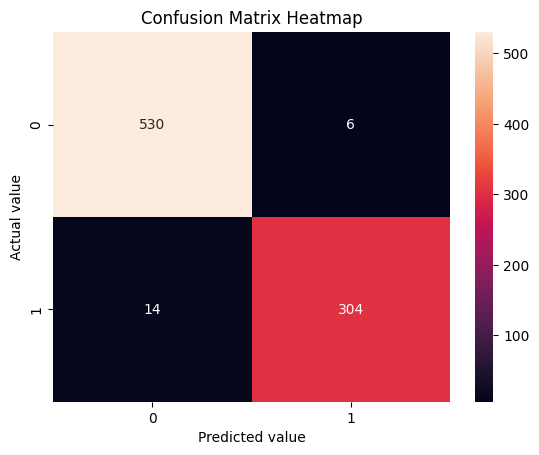

In [ ]:
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.show()

In [ ]:
no_of_dependents = int(input("no_of_dependents: "))
education = int(input("Education (0 Graduate, 1 Not Graduate): "))
self_employed = int(input("Self Employed (0 No, 1 Yes): "))
income_annum = float(input("Applicant Income: "))
loan_amount = float(input("Loan Amount: "))
loan_term = float(input("Loan Term: "))
cibil_score = float(input("cibil_score: "))
residential_assets_value = float(input(" residential_assets_value: "))
commercial_assets_value = float(input("commercial_assets_value: "))
luxury_assets_value = float(input("luxury_assets_value: "))
bank_assets_value = float(input("bank_assets_value: "))
data  = pd.DataFrame([[no_of_dependents,  education,  self_employed, income_annum,        #Create DataFrame from User Input
       loan_amount,  loan_term,  cibil_score,
        residential_assets_value , commercial_assets_value,
        luxury_assets_value, bank_assets_value]],
        columns=X.columns)

prediction =model.predict(data)                        #Predict New Data

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")